In [ ]:
# --- repo-root bootstrap ---
# This notebook lives in 05_analysis/ but reads and writes paths relative to
# the repo root (data/, metrics_data/, outputs/, figures_*/) and imports
# modules from the repo root and 04_metrics/. Jupyter's working directory is
# the notebook's own folder, so without this cell those paths resolve under
# 05_analysis/ and the imports fail. Idempotent - safe to re-run.
import os, sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "config.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
for _p in (REPO_ROOT, REPO_ROOT / "04_metrics"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))
print(f"repo root: {REPO_ROOT}")


In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.patches as mpatches
from utils import *
import matplotlib.colors as mcolors



In [2]:
def visualize(dimensions, problems, algorithms, runs,
              line_plot_y=False, plot_y=False, data_dir=None, save=False,
              popsize=50, fig_dir='figures_clustering_new_kmeans'):
    """
    For each (dimension, problem, algorithm, run): plot the cluster-occupancy
    heatmap (agents per cluster per iteration), optionally alongside the
    per-cluster best scaled fitness (as a line plot or heatmap).
    """
    if data_dir is None:
        data_dir = 'data/clustering_latest'

    for dimension in dimensions:
        directory = f'{data_dir}/cluster_distributions/dim_{dimension}'

        for problem in problems:
            # ---- cluster centers (used to label cluster columns) ----
            centers_path = f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv'
            if not os.path.isfile(centers_path):
                print(f"  missing cluster centers: {centers_path}")
                continue
            cluster_centers = pd.read_csv(centers_path, index_col=0)
            cluster_centers = {
                index: ', '.join(str(round(row[c], 2)) for c in row.keys())
                for index, row in cluster_centers.iterrows()
            }

            solutions = pd.read_parquet(
                f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')

            file_loc = f'{directory}/{problem}.csv'
            if not os.path.isfile(file_loc):
                print(f"  missing cluster distributions: {file_loc}")
                continue

            df = pd.read_csv(file_loc, index_col=[0, 1, 2])
            df.columns = [f'{int(c)} ({cluster_centers[int(c)]})' for c in df.columns]

            for a in algorithms:
                for run in runs:
                    # ---- guard: this (algorithm, run) may not exist ----
                    try:
                        occupancy = df.loc[a, run]
                    except KeyError:
                        print(f"  no data for {problem} / {a} / run {run}, skipping")
                        continue

                    s = (solutions.query('algorithm==@a and run==@run')
                         .groupby(['iteration', 'cluster'])['scaled_raw_y'])
                    s_min = s.min().cummin().to_frame().reset_index()
                    if s_min.empty:
                        print(f"  no solutions for {problem} / {a} / run {run}, skipping")
                        continue

                    # ---- figure size: scale height with the number of ITERATIONS
                    # (rows of the heatmap), not an arbitrary divisor. Guarded so
                    # an empty/NaN max can't blow up int().
                    n_iters = int(occupancy.shape[0])
                    fig_h = max(6, n_iters * 0.35)
                    fig_w = 16 if plot_y else 9

                    fig, axes = plt.subplots(1, 2 if plot_y else 1,
                                             figsize=(fig_w, fig_h), squeeze=False)
                    axes = axes[0]

                    # ---- left: cluster occupancy heatmap ----
                    sns.heatmap(occupancy.replace(0, np.nan), annot=True, fmt='.0f',
                                ax=axes[0], cmap='YlGnBu', vmin=0, vmax=popsize,
                                cbar_kws={'label': 'število agentov v gruči'})
                    axes[0].set_title(f'{a} — zagon {run} — {problem} (dim {dimension})\n'
                                      f'zasedenost gruč',
                                      fontsize=11, fontweight='bold')
                    axes[0].set_xlabel('Gruča')
                    axes[0].set_ylabel('Iteracija')

                    # ---- right (optional): best scaled fitness per cluster ----
                    if plot_y:
                        if line_plot_y:
                            sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y',
                                         hue='cluster', style='cluster', palette='tab10',
                                         markers=True, dashes=False, ax=axes[1])
                            axes[1].set_xlabel('Iteracija')
                            axes[1].set_ylabel('Skalirana vrednost y (tekoči minimum)')
                        else:
                            s_min_pivoted = s_min.pivot(index='iteration', columns='cluster',
                                                        values='scaled_raw_y')
                            s_min_pivoted.columns = [
                                f'{int(c)} ({cluster_centers[int(c)]})'
                                for c in s_min_pivoted.columns
                            ]
                            # LogNorm can't handle <=0; clip to a small positive floor
                            plot_vals = s_min_pivoted.clip(lower=1e-8)
                            sns.heatmap(plot_vals, annot=True, ax=axes[1], cmap='YlGnBu',
                                        fmt='.3f', norm=mcolors.LogNorm(),
                                        cbar_kws={'label': 'skalirana vrednost y (log)'})
                            axes[1].set_xlabel('Gruča')
                            axes[1].set_ylabel('Iteracija')

                        axes[1].set_title(f'{a} — zagon {run} — {problem} (dim {dimension})\n'
                                          f'najboljši skalirani fitness po gruči',
                                          fontsize=11, fontweight='bold')

                    plt.tight_layout()

                    if save:
                        os.makedirs(fig_dir, exist_ok=True)
                        file_name = f'{problem}_{a}_run_{run}_dim_{dimension}.pdf'
                        plt.savefig(f'{fig_dir}/{file_name}', bbox_inches='tight')

                    plt.show()
                    plt.close(fig)

In [3]:
def visualize_multi(dimensions, problems, algorithms, runs,
                    line_plot_y=False, plot_y=False, data_dir=None, save=False,
                    popsize=50, fig_dir='figures_clustering_new_kmeans'):
    """
    Same as visualize(), but stacks all algorithms into ONE figure (one row per
    algorithm) so they can be compared side by side on the same problem/run.
    """
    if data_dir is None:
        data_dir = 'data/clustering_latest'

    for dimension in dimensions:
        directory = f'{data_dir}/cluster_distributions/dim_{dimension}'

        for problem in problems:
            centers_path = f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv'
            if not os.path.isfile(centers_path):
                print(f"  missing cluster centers: {centers_path}")
                continue
            cluster_centers = pd.read_csv(centers_path, index_col=0)
            cluster_count = cluster_centers.shape[0]
            cluster_centers = {
                index: ', '.join(str(round(row[c], 2)) for c in row.keys())
                for index, row in cluster_centers.iterrows()
            }

            solutions = pd.read_parquet(
                f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')

            file_loc = f'{directory}/{problem}.csv'
            if not os.path.isfile(file_loc):
                print(f"  missing cluster distributions: {file_loc}")
                continue

            df = pd.read_csv(file_loc, index_col=[0, 1, 2])
            df.columns = [f'{int(c)} ({cluster_centers[int(c)]})' for c in df.columns]

            for run in runs:
                # ---- figure size: height scales with the NUMBER OF ALGORITHMS
                # (one row each), width scales with cluster count. Bumped up
                # from the earlier sizing now that column labels are shorter
                # (Center: text removed, coordinates kept) but still need
                # breathing room.
                n_rows = len(algorithms)
                fig_w = max(18, cluster_count * 1.5) if plot_y else 14
                fig_h = 6 * n_rows

                fig, all_axes = plt.subplots(n_rows, 2 if plot_y else 1,
                                             figsize=(fig_w, fig_h),
                                             squeeze=False, sharex=False)

                for a_index, a in enumerate(algorithms):
                    axes = all_axes[a_index]

                    try:
                        occupancy = df.loc[a, run]
                    except KeyError:
                        print(f"  no data for {problem} / {a} / run {run}, skipping row")
                        axes[0].set_visible(False)
                        if plot_y:
                            axes[1].set_visible(False)
                        continue

                    s = (solutions.query('algorithm==@a and run==@run')
                         .groupby(['iteration', 'cluster'])['scaled_raw_y'])
                    s_min = s.min().to_frame().reset_index()

                    # ---- left: cluster occupancy ----
                    sns.heatmap(occupancy.replace(0, np.nan), annot=True, fmt='.0f',
                                ax=axes[0], vmin=0, vmax=popsize, cmap='YlGnBu',
                                cbar_kws={'label': 'število agentov v gruči'})
                    axes[0].set_title(f'{a} — zagon {run} — {problem} (dim {dimension}): '
                                      f'zasedenost gruč',
                                      fontsize=11, fontweight='bold')
                    axes[0].set_xlabel('Gruča')
                    axes[0].set_ylabel('Iteracija')

                    # ---- right (optional): best scaled fitness per cluster ----
                    if plot_y:
                        if s_min.empty:
                            axes[1].set_visible(False)
                            continue
                        if line_plot_y:
                            sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y',
                                         hue='cluster', style='cluster', palette='tab10',
                                         markers=True, dashes=False, ax=axes[1])
                            axes[1].set_xlabel('Iteracija')
                            axes[1].set_ylabel('Skalirana vrednost y')
                        else:
                            s_min_pivoted = s_min.pivot(index='iteration', columns='cluster',
                                                        values='scaled_raw_y')
                            s_min_pivoted.columns = [
                                f'{int(c)} ({cluster_centers[int(c)]})'
                                for c in s_min_pivoted.columns
                            ]
                            sns.heatmap(s_min_pivoted, annot=True, fmt='.2f', ax=axes[1],
                                        vmin=0, vmax=1, cmap='YlGnBu',
                                        cbar_kws={'label': 'skalirana vrednost y'})
                            axes[1].set_xlabel('Gruča')
                            axes[1].set_ylabel('Iteracija')

                        axes[1].set_title(f'{a} — zagon {run}: najnižja skalirana vrednost y po gruči',
                                          fontsize=11, fontweight='bold')

                plt.tight_layout()

                if save:
                    os.makedirs(fig_dir, exist_ok=True)
                    algo_str = '+'.join(algorithms)
                    file_name = (f"{data_dir.split('/')[-1]}_{problem}_{algo_str}"
                                 f"_run_{run}_dim_{dimension}.pdf")
                    plt.savefig(f'{fig_dir}/{file_name}', bbox_inches='tight')

                plt.show()
                plt.close(fig)

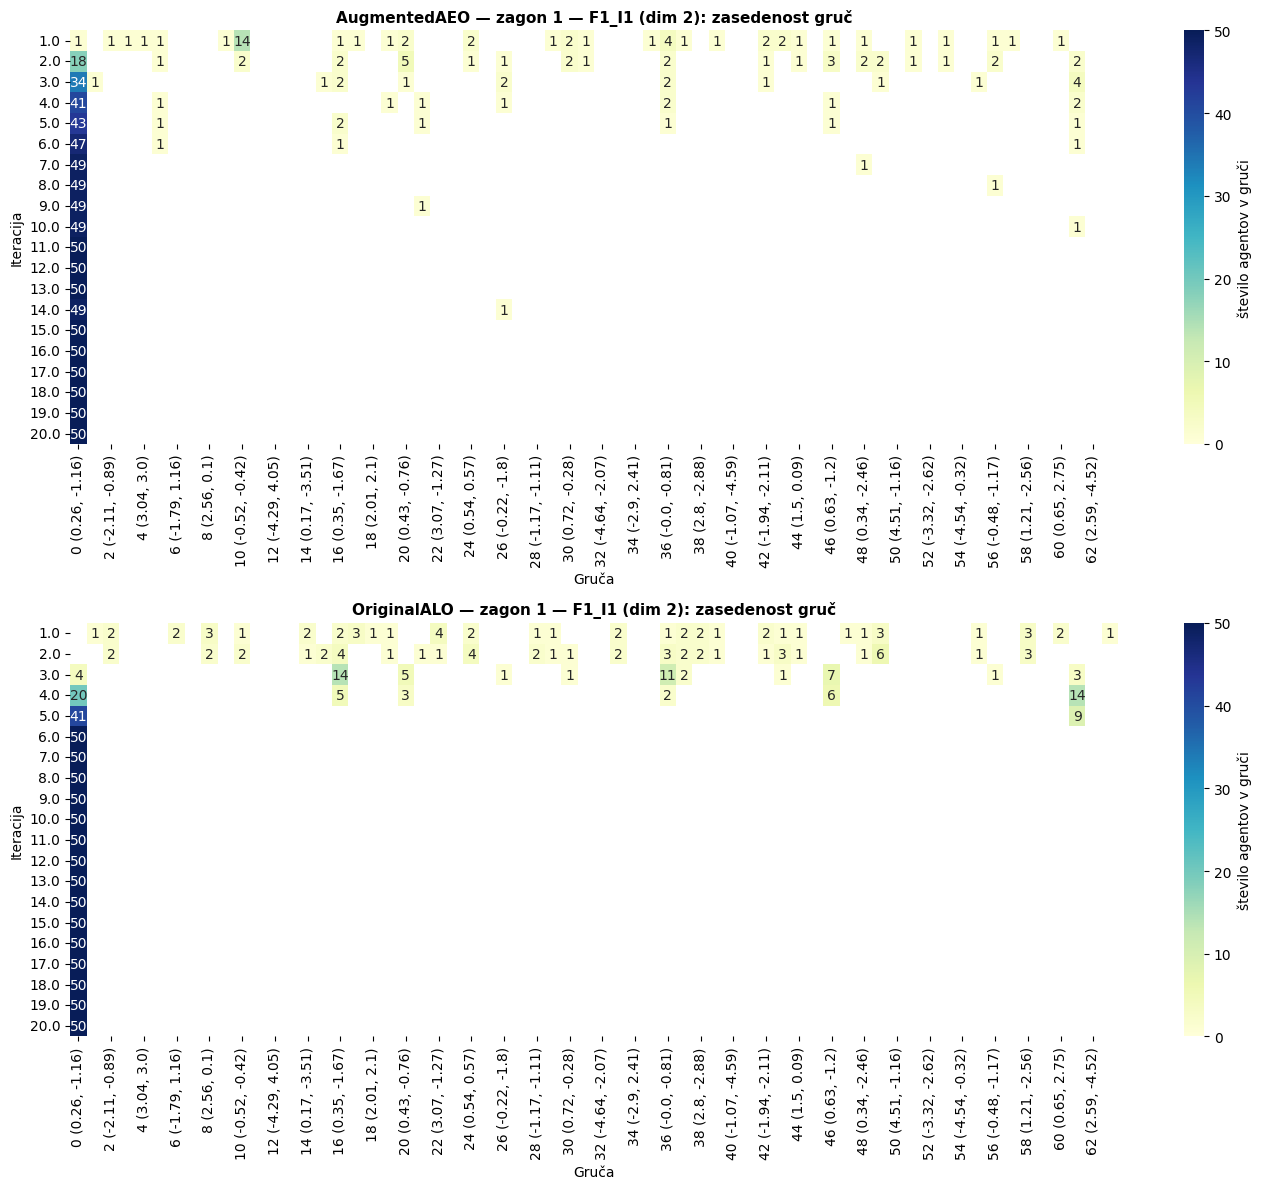

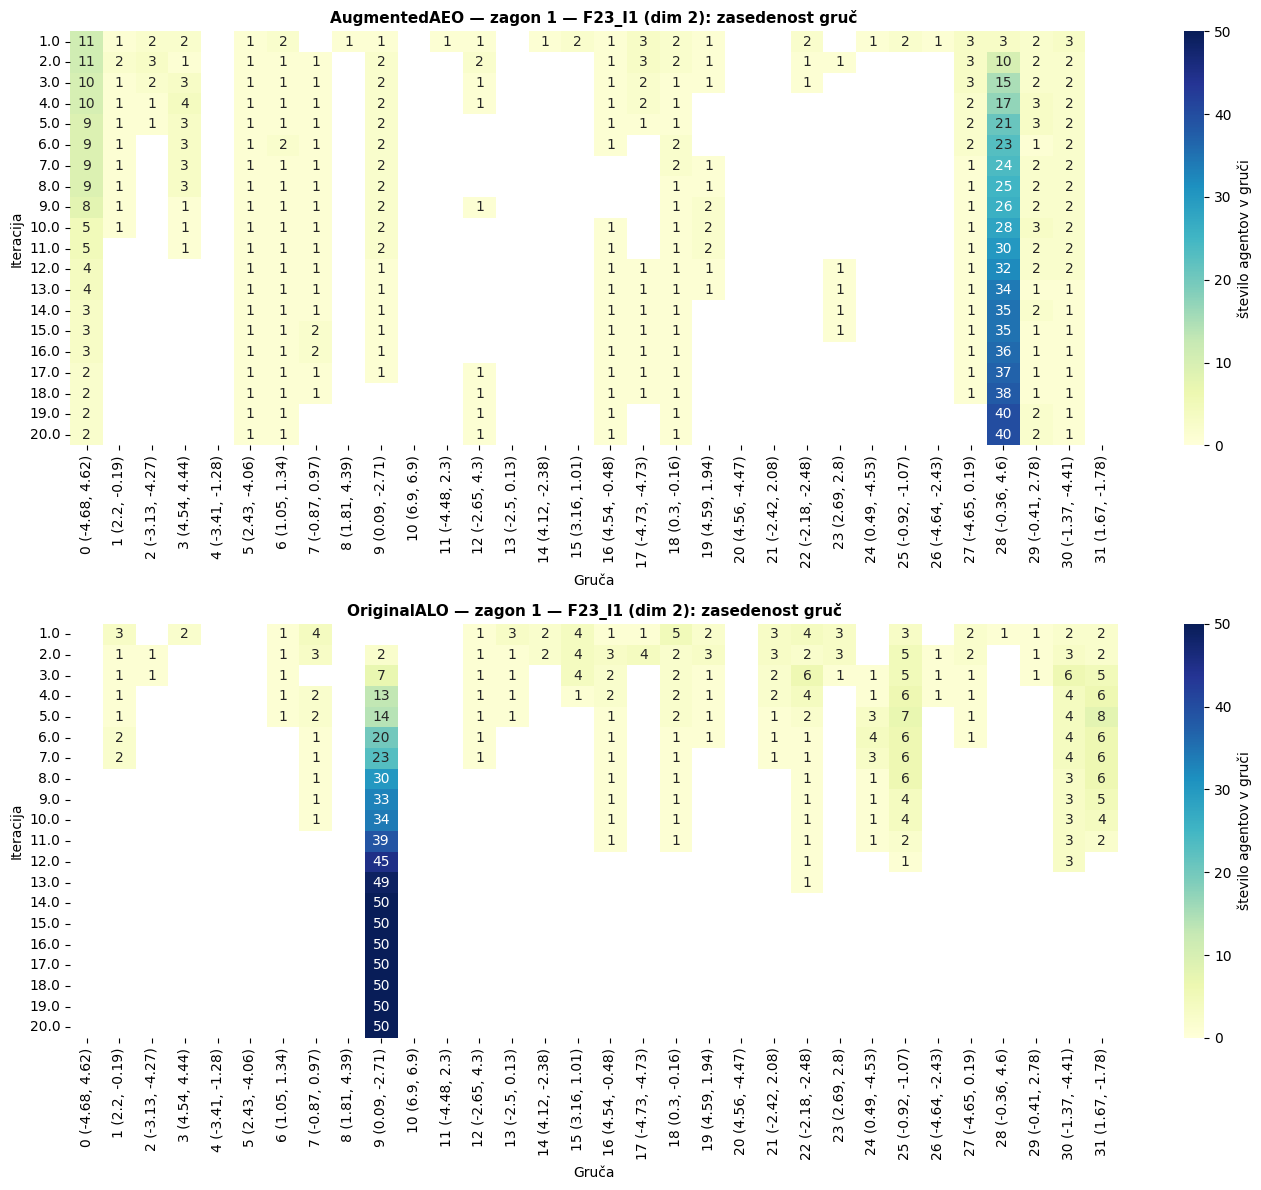

In [4]:
visualize_multi(
    dimensions=[2],
    problems=['F1_I1', 'F23_I1'],
    algorithms=['AugmentedAEO', 'OriginalALO'],
    runs=[1],
    plot_y=False,      # samo zasedenost gruč, brez desnega panela
    save=True,
)

In [60]:
ALGORITHMS_OF_INTEREST=["OriginalDE","SADE","OriginalSHADE", "JADE","AugmentedAEO", "GWO_WOA", "OriginalGWO", "OriginalMRFO", "OriginalALO", "OriginalAEO"]


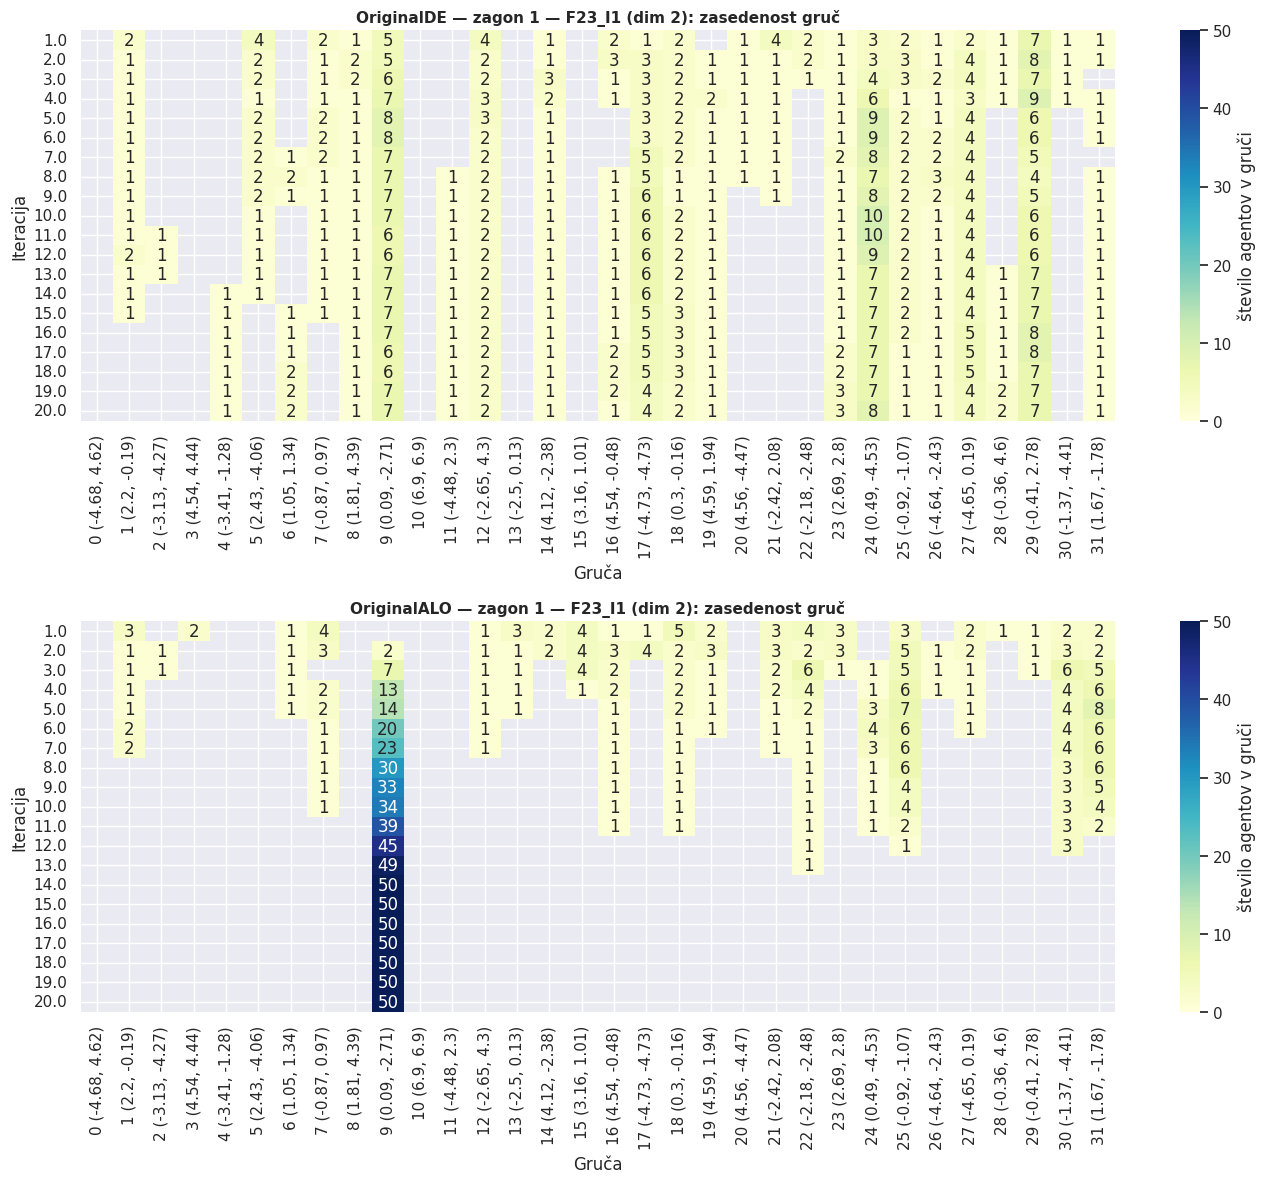

In [40]:
visualize_multi([2], ['F23_I1'], ['OriginalDE', 'OriginalALO'], [1], data_dir=f'data/clustering_latest', save=True)

In [42]:
dimension = 10
directory = f'data/clustering_latest/cluster_distributions/dim_{dimension}'
trajectory_similarities = []

for file in tqdm(os.listdir(directory)):
    file_loc = f'{directory}/{file}'
    if os.path.isfile(file_loc):
        df = pd.read_csv(file_loc, index_col=[0, 1, 2])

        # filtriraj na samo algoritme iz ALGORITHMS_OF_INTEREST, PREDEN
        # zgradimo kosinusno matriko (hitreje, in izognemo se podobnosti,
        # ki jo bomo itak zavrgli)
        df = df[df.index.get_level_values('algorithm').isin(ALGORITHMS_OF_INTEREST)]
        if df.empty:
            continue

        d_algorithm_run = df.unstack(level=-1).dropna()
        #d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
        cs = pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
        c = (cs.reset_index()
               .rename(columns={'algorithm': 'algorithm2', 'run': 'run2'})
               .melt(id_vars=[('algorithm2', ''), ('run2', '')], value_vars=list(cs.columns))
               .rename(columns={('algorithm2', ''): 'algorithm2', ('run2', ''): 'run2'}))
        trajectory_similarities += [c.assign(problem=file.replace('.csv', ''))]

trajectory_similarities = pd.concat(trajectory_similarities)

t = trajectory_similarities.groupby('algorithm').count()['run']
t_max = t.max()
algorithms_to_remove = list(t[t < t_max].index)
trajectory_similarities = trajectory_similarities.query(
    'algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')

trajectory_similarities['problem_class'] = [int(tt.split('_')[0].replace('F', '')) for tt in trajectory_similarities['problem']]
trajectory_similarities['instance'] = [int(tt.split('_')[1].replace('I', '')) for tt in trajectory_similarities['problem']]
trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

100%|██████████| 120/120 [00:24<00:00,  4.88it/s]


In [43]:
trajectory_similarities.query('algorithm!=algorithm2').sort_values('value')

,algorithm2,run2,algorithm,run,value,problem,problem_class,instance
1139,OriginalDE,5,OriginalMRFO,4,0.000000,F8_I3,8,3
1043,AugmentedAEO,4,OriginalMRFO,2,0.000000,F8_I1,8,1
146,OriginalMRFO,2,AugmentedAEO,4,0.000000,F8_I1,8,1
788,OriginalMRFO,4,OriginalDE,5,0.000000,F8_I3,8,3
106,OriginalMRFO,2,AugmentedAEO,3,0.000004,F12_I3,12,3
...,...,...,...,...,...,...,...,...
200,AugmentedAEO,1,GWO_WOA,1,0.998398,F22_I3,22,3
1160,AugmentedAEO,1,OriginalMRFO,5,0.999422,F22_I4,22,4
29,OriginalMRFO,5,AugmentedAEO,1,0.999422,F22_I4,22,4
1123,AugmentedAEO,4,OriginalMRFO,4,0.999490,F21_I5,21,5


100%|██████████| 120/120 [00:30<00:00,  3.90it/s]


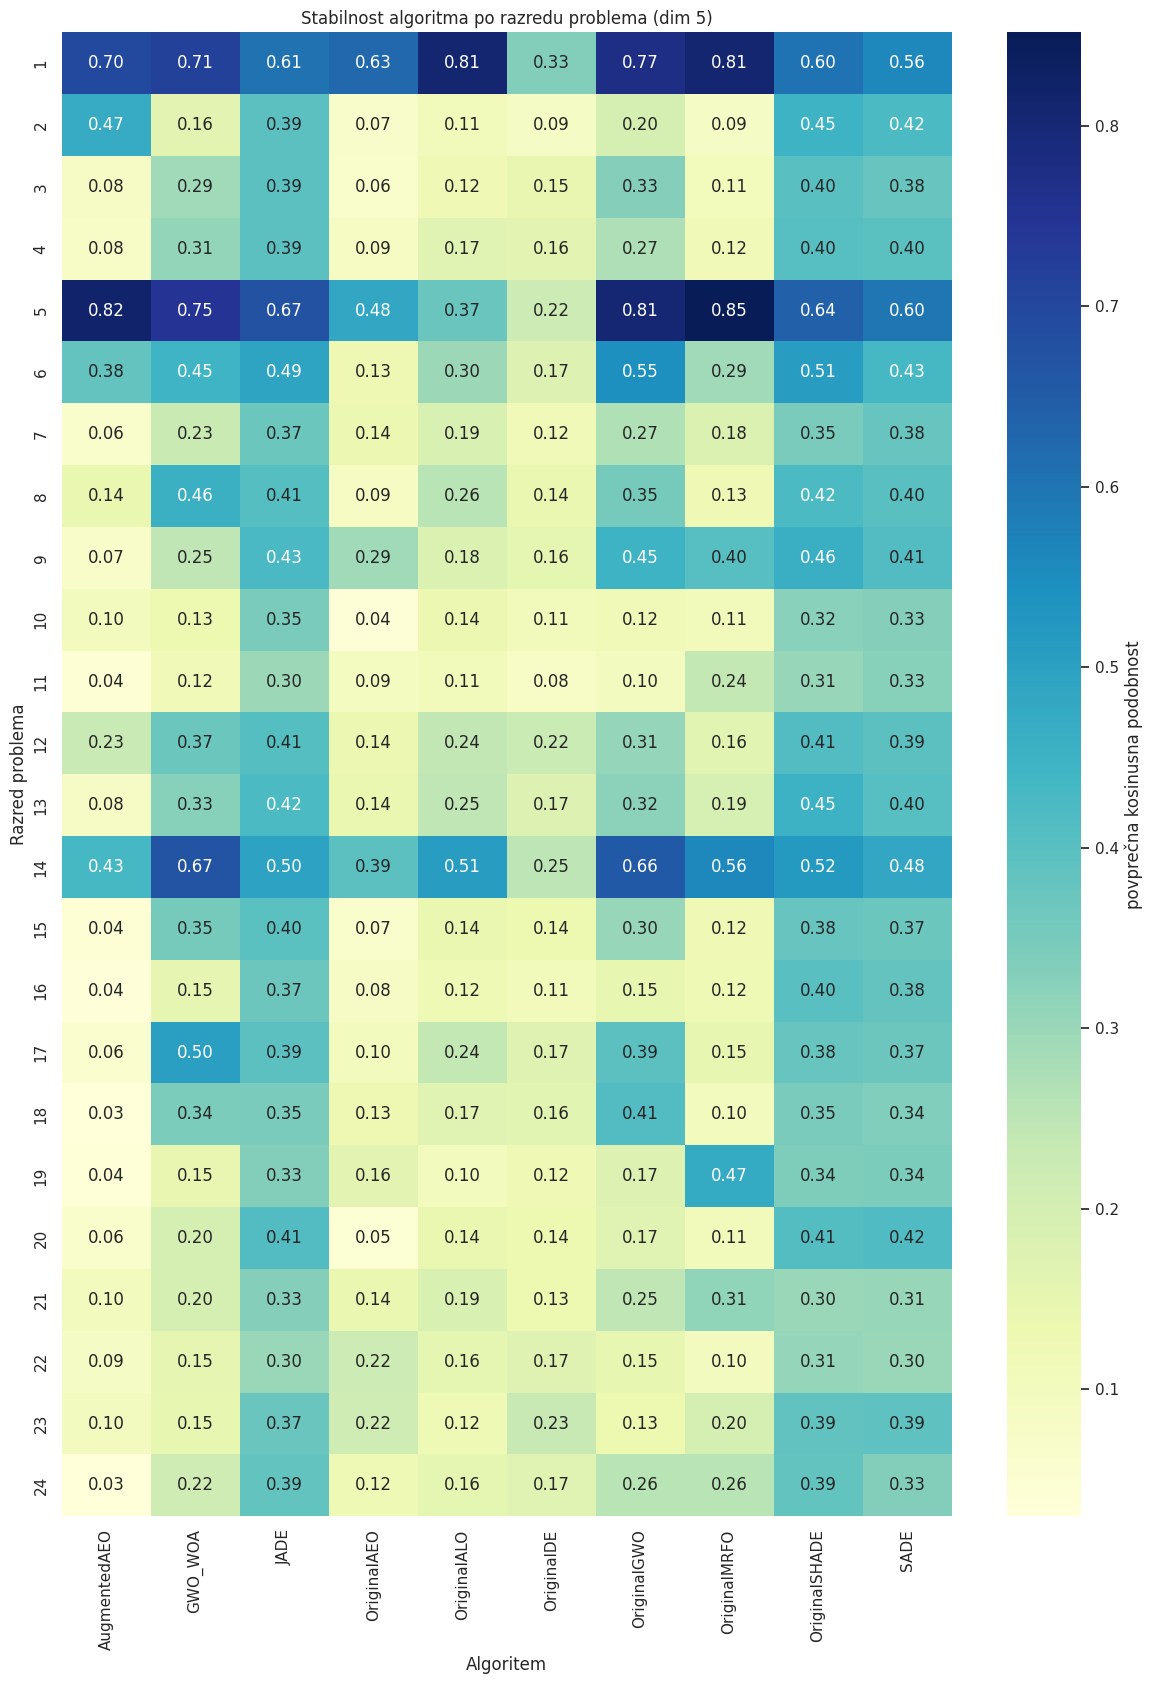

<Figure size 1500x1500 with 0 Axes>

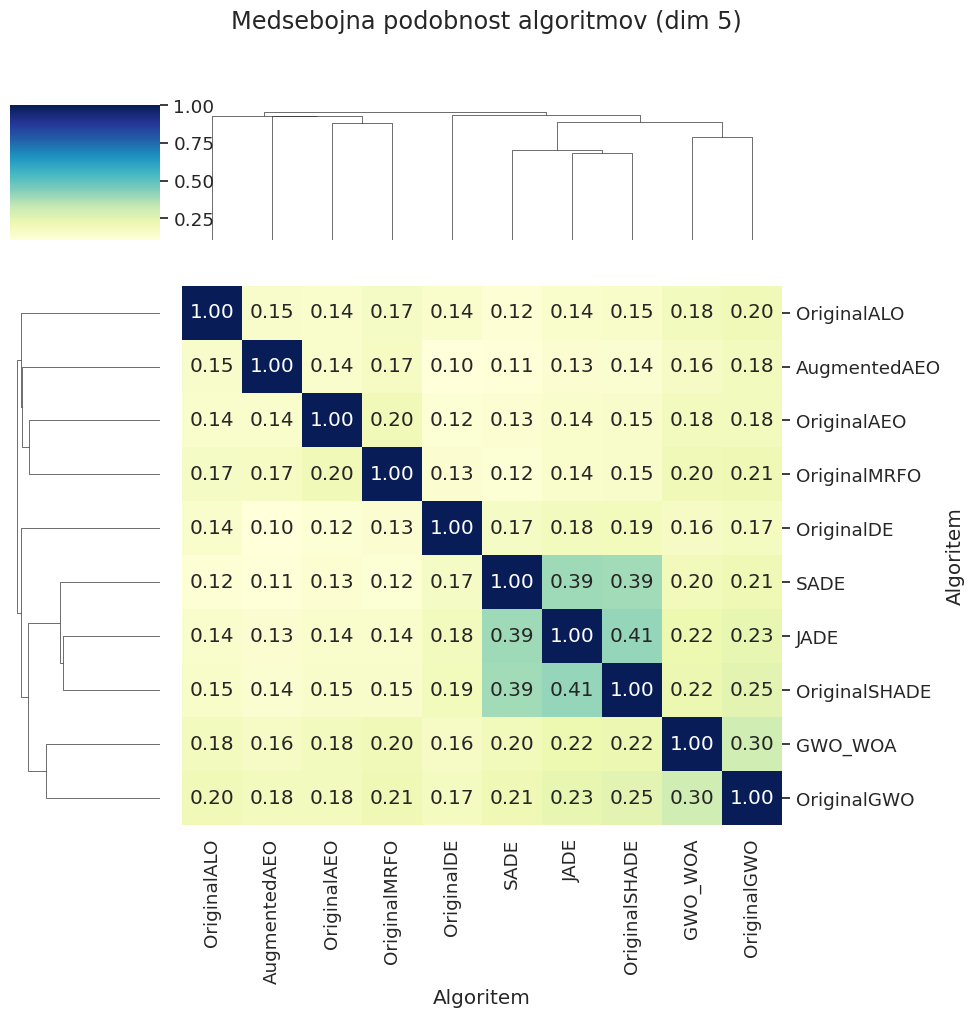

In [62]:
for dimension in [5]:
    os.makedirs('figures_clustering_new_kmeans', exist_ok=True)
    directory = f'data/clustering_latest/cluster_distributions/dim_{dimension}'
    scale = False
    trajectory_similarities = []
    for file in tqdm(os.listdir(directory)):
        file_loc = f'{directory}/{file}'
        if os.path.isfile(file_loc):
            df = pd.read_csv(file_loc, index_col=[0, 1, 2])
            # filtriraj na samo algoritme iz ALGORITHMS_OF_INTEREST, PREDEN
            # zgradimo kosinusno matriko
            df = df[df.index.get_level_values('algorithm').isin(ALGORITHMS_OF_INTEREST)]
            if df.empty:
                continue
            d_algorithm_run = df.unstack(level=-1).dropna()
            d_algorithm_run = pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
            cs = pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
            c = cs.reset_index().rename(columns={'algorithm': 'algorithm2', 'run': 'run2'}).melt(id_vars=[('algorithm2', ''), ('run2', '')], value_vars=list(cs.columns)).rename(columns={('algorithm2', ''): 'algorithm2', ('run2', ''): 'run2'})
            trajectory_similarities += [c.assign(problem=file.replace('.csv', ''))]
    trajectory_similarities = pd.concat(trajectory_similarities)
    t = trajectory_similarities.groupby('algorithm').count()['run']
    t_max = t.max()
    algorithms_to_remove = list(t[t < t_max].index)
    trajectory_similarities = trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
    trajectory_similarities['problem_class'] = [int(tt.split('_')[0].replace('F', '')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['instance'] = [int(tt.split('_')[1].replace('I', '')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
    trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

    plt.figure(figsize=(12, 17))
    sim_per_problem_algorithm = trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class', 'algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class', columns='algorithm', values='value').sort_index(),
                annot=True, fmt=".2f", cmap='YlGnBu',
                cbar_kws={'label': 'povprečna kosinusna podobnost'})
    plt.title(f'Stabilnost algoritma po razredu problema (dim {dimension})')
    plt.xlabel('Algoritem')
    plt.ylabel('Razred problema')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_kmeans/algorithm_similarity_per_problem_dim_{dimension}_scale_{scale}.pdf', bbox_inches='tight')

    cross_algorithm_similarity = trajectory_similarities.query('run==run2').groupby(['algorithm', 'algorithm2'])['value'].mean()
    cross_algorithm_similarity_pivoted = cross_algorithm_similarity.reset_index().pivot(index='algorithm', columns='algorithm2', values='value')
    sns.set_theme(font_scale=1.2)
    plt.figure(figsize=(15, 15))
    g = sns.clustermap(cross_algorithm_similarity_pivoted, annot=True, fmt=".2f", cmap='YlGnBu')
    g.ax_heatmap.set_xlabel('Algoritem')
    g.ax_heatmap.set_ylabel('Algoritem')
    g.figure.suptitle(f'Medsebojna podobnost algoritmov (dim {dimension})', y=1.02)
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_kmeans/algorithm_mean_similarity_clustermap_dim_{dimension}_scale_{scale}.pdf', bbox_inches='tight')
    sns.set_theme(font_scale=1)

In [46]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

FIG_DIR = 'figures_clustering_new_kmeans'

# ALGORITHMS_OF_INTEREST mora biti definiran prej v notebooku/skripti
for dimension in [5,10]:
    os.makedirs(FIG_DIR, exist_ok=True)
    directory = f'data/clustering_latest/cluster_distributions/dim_{dimension}'
    scale = False

    # ---- build pairwise cosine similarities across all problems ----
    trajectory_similarities = []
    for file in tqdm(os.listdir(directory)):
        file_loc = f'{directory}/{file}'
        if not os.path.isfile(file_loc):
            continue
        df = pd.read_csv(file_loc, index_col=[0, 1, 2])

        # filtriraj na samo algoritme iz ALGORITHMS_OF_INTEREST, PREDEN
        # zgradimo kosinusno matriko (hitreje, ne rabimo podobnosti za
        # algoritme, ki jih bomo itak zavrgli)
        df = df[df.index.get_level_values('algorithm').isin(ALGORITHMS_OF_INTEREST)]
        if df.empty:
            continue

        d_algorithm_run = df.unstack(level=-1).dropna()
        d_algorithm_run = pd.DataFrame(
            MinMaxScaler().fit_transform(d_algorithm_run),
            index=d_algorithm_run.index,
            columns=d_algorithm_run.columns
        ).dropna()
        cs = pd.DataFrame(cosine_similarity(d_algorithm_run),
                          index=d_algorithm_run.index,
                          columns=d_algorithm_run.index)
        c = (cs.reset_index()
               .rename(columns={'algorithm': 'algorithm2', 'run': 'run2'})
               .melt(id_vars=[('algorithm2', ''), ('run2', '')], value_vars=list(cs.columns))
               .rename(columns={('algorithm2', ''): 'algorithm2', ('run2', ''): 'run2'}))
        trajectory_similarities += [c.assign(problem=file.replace('.csv', ''))]

    trajectory_similarities = pd.concat(trajectory_similarities)

    # drop algorithms with incomplete coverage
    t = trajectory_similarities.groupby('algorithm').count()['run']
    t_max = t.max()
    algorithms_to_remove = list(t[t < t_max].index)
    trajectory_similarities = trajectory_similarities.query(
        'algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')

    trajectory_similarities['problem_class'] = [
        int(tt.split('_')[0].replace('F', '')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['instance'] = [
        int(tt.split('_')[1].replace('I', '')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
    trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

    # =====================================================================
    # SLIKA 1: samo-podobnost po (razred problema x algoritem)
    # =====================================================================
    ANNOT_FIG1 = True

    sim_per_problem_algorithm = (trajectory_similarities
                                 .query('algorithm==algorithm2 and run!=run2')
                                 .groupby(['problem_class', 'algorithm'])['value'].mean())
    pivot1 = (sim_per_problem_algorithm.reset_index()
              .pivot(index='problem_class', columns='algorithm', values='value')
              .sort_index())

    n_algos = pivot1.shape[1]
    fig_w = max(12, n_algos * 0.75)
    plt.figure(figsize=(fig_w, 14))
    sns.heatmap(pivot1, annot=ANNOT_FIG1, fmt=".2f", cmap='YlGnBu',
                annot_kws={'size': 6} if ANNOT_FIG1 else None,
                cbar_kws={'label': 'povprečna kosinusna podobnost (isti algoritem, različna zagona)'})
    plt.title(f'Stabilnost algoritma po razredu problema (dim {dimension})')
    plt.xlabel('Algoritem')
    plt.ylabel('Razred problema')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/algorithm_similarity_per_problem_dim_{dimension}_scale_{scale}.pdf',
                bbox_inches='tight')
    plt.close()

    # =====================================================================
    # SLIKA 2: clustermap med algoritmi (N x N)
    # =====================================================================
    cross_algorithm_similarity = (trajectory_similarities
                                  .query('run==run2')
                                  .groupby(['algorithm', 'algorithm2'])['value'].mean())
    pivot2 = (cross_algorithm_similarity.reset_index()
              .pivot(index='algorithm', columns='algorithm2', values='value'))

    n = pivot2.shape[0]

    sns.set_theme(font_scale=1.0)
    g = sns.clustermap(pivot2, annot=False, cmap='YlGnBu',
                       figsize=(max(12, n * 0.5), max(12, n * 0.5)),
                       cbar_kws={'label': 'povprečna kosinusna podobnost'})

    row_order = g.dendrogram_row.reordered_ind
    g.ax_heatmap.set_yticks([i + 0.5 for i in range(n)])
    g.ax_heatmap.set_yticklabels([pivot2.index[i] for i in row_order],
                                 fontsize=8, rotation=0)

    col_order = g.dendrogram_col.reordered_ind
    g.ax_heatmap.set_xticks([i + 0.5 for i in range(pivot2.shape[1])])
    g.ax_heatmap.set_xticklabels([pivot2.columns[i] for i in col_order],
                                 fontsize=8, rotation=45, ha='right')

    g.ax_heatmap.set_xlabel('')
    g.ax_heatmap.set_ylabel('')
    g.figure.suptitle(f'Medsebojna podobnost algoritmov (dim {dimension})', y=1.02)

    g.savefig(f'{FIG_DIR}/algorithm_mean_similarity_clustermap_dim_{dimension}_scale_{scale}.pdf',
              bbox_inches='tight')
    plt.close()
    sns.set_theme(font_scale=1)

    print(f"dim {dimension}: {n} algoritmov prikazanih")
    print(f"  odstranjeni (nepopolna pokritost): {algorithms_to_remove}")

100%|██████████| 120/120 [00:21<00:00,  5.55it/s]


dim 5: 8 algoritmov prikazanih
  odstranjeni (nepopolna pokritost): []


100%|██████████| 120/120 [00:35<00:00,  3.42it/s]


dim 10: 8 algoritmov prikazanih
  odstranjeni (nepopolna pokritost): []


In [47]:
optimizer_group=get_algorithm_groups()


In [48]:
cross_algorithm_similarity_to_save=cross_algorithm_similarity.reset_index()
cross_algorithm_similarity_to_save['algorithm_group']=cross_algorithm_similarity_to_save['algorithm'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save['algorithm2_group']=cross_algorithm_similarity_to_save['algorithm2'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save.sort_values('value',ascending=False).query('algorithm!=algorithm2').to_csv(f'data/clustering_latest/algorithm_pairwise_similarity/algorithm_mean_similarity_{dimension}D.csv')

In [49]:

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

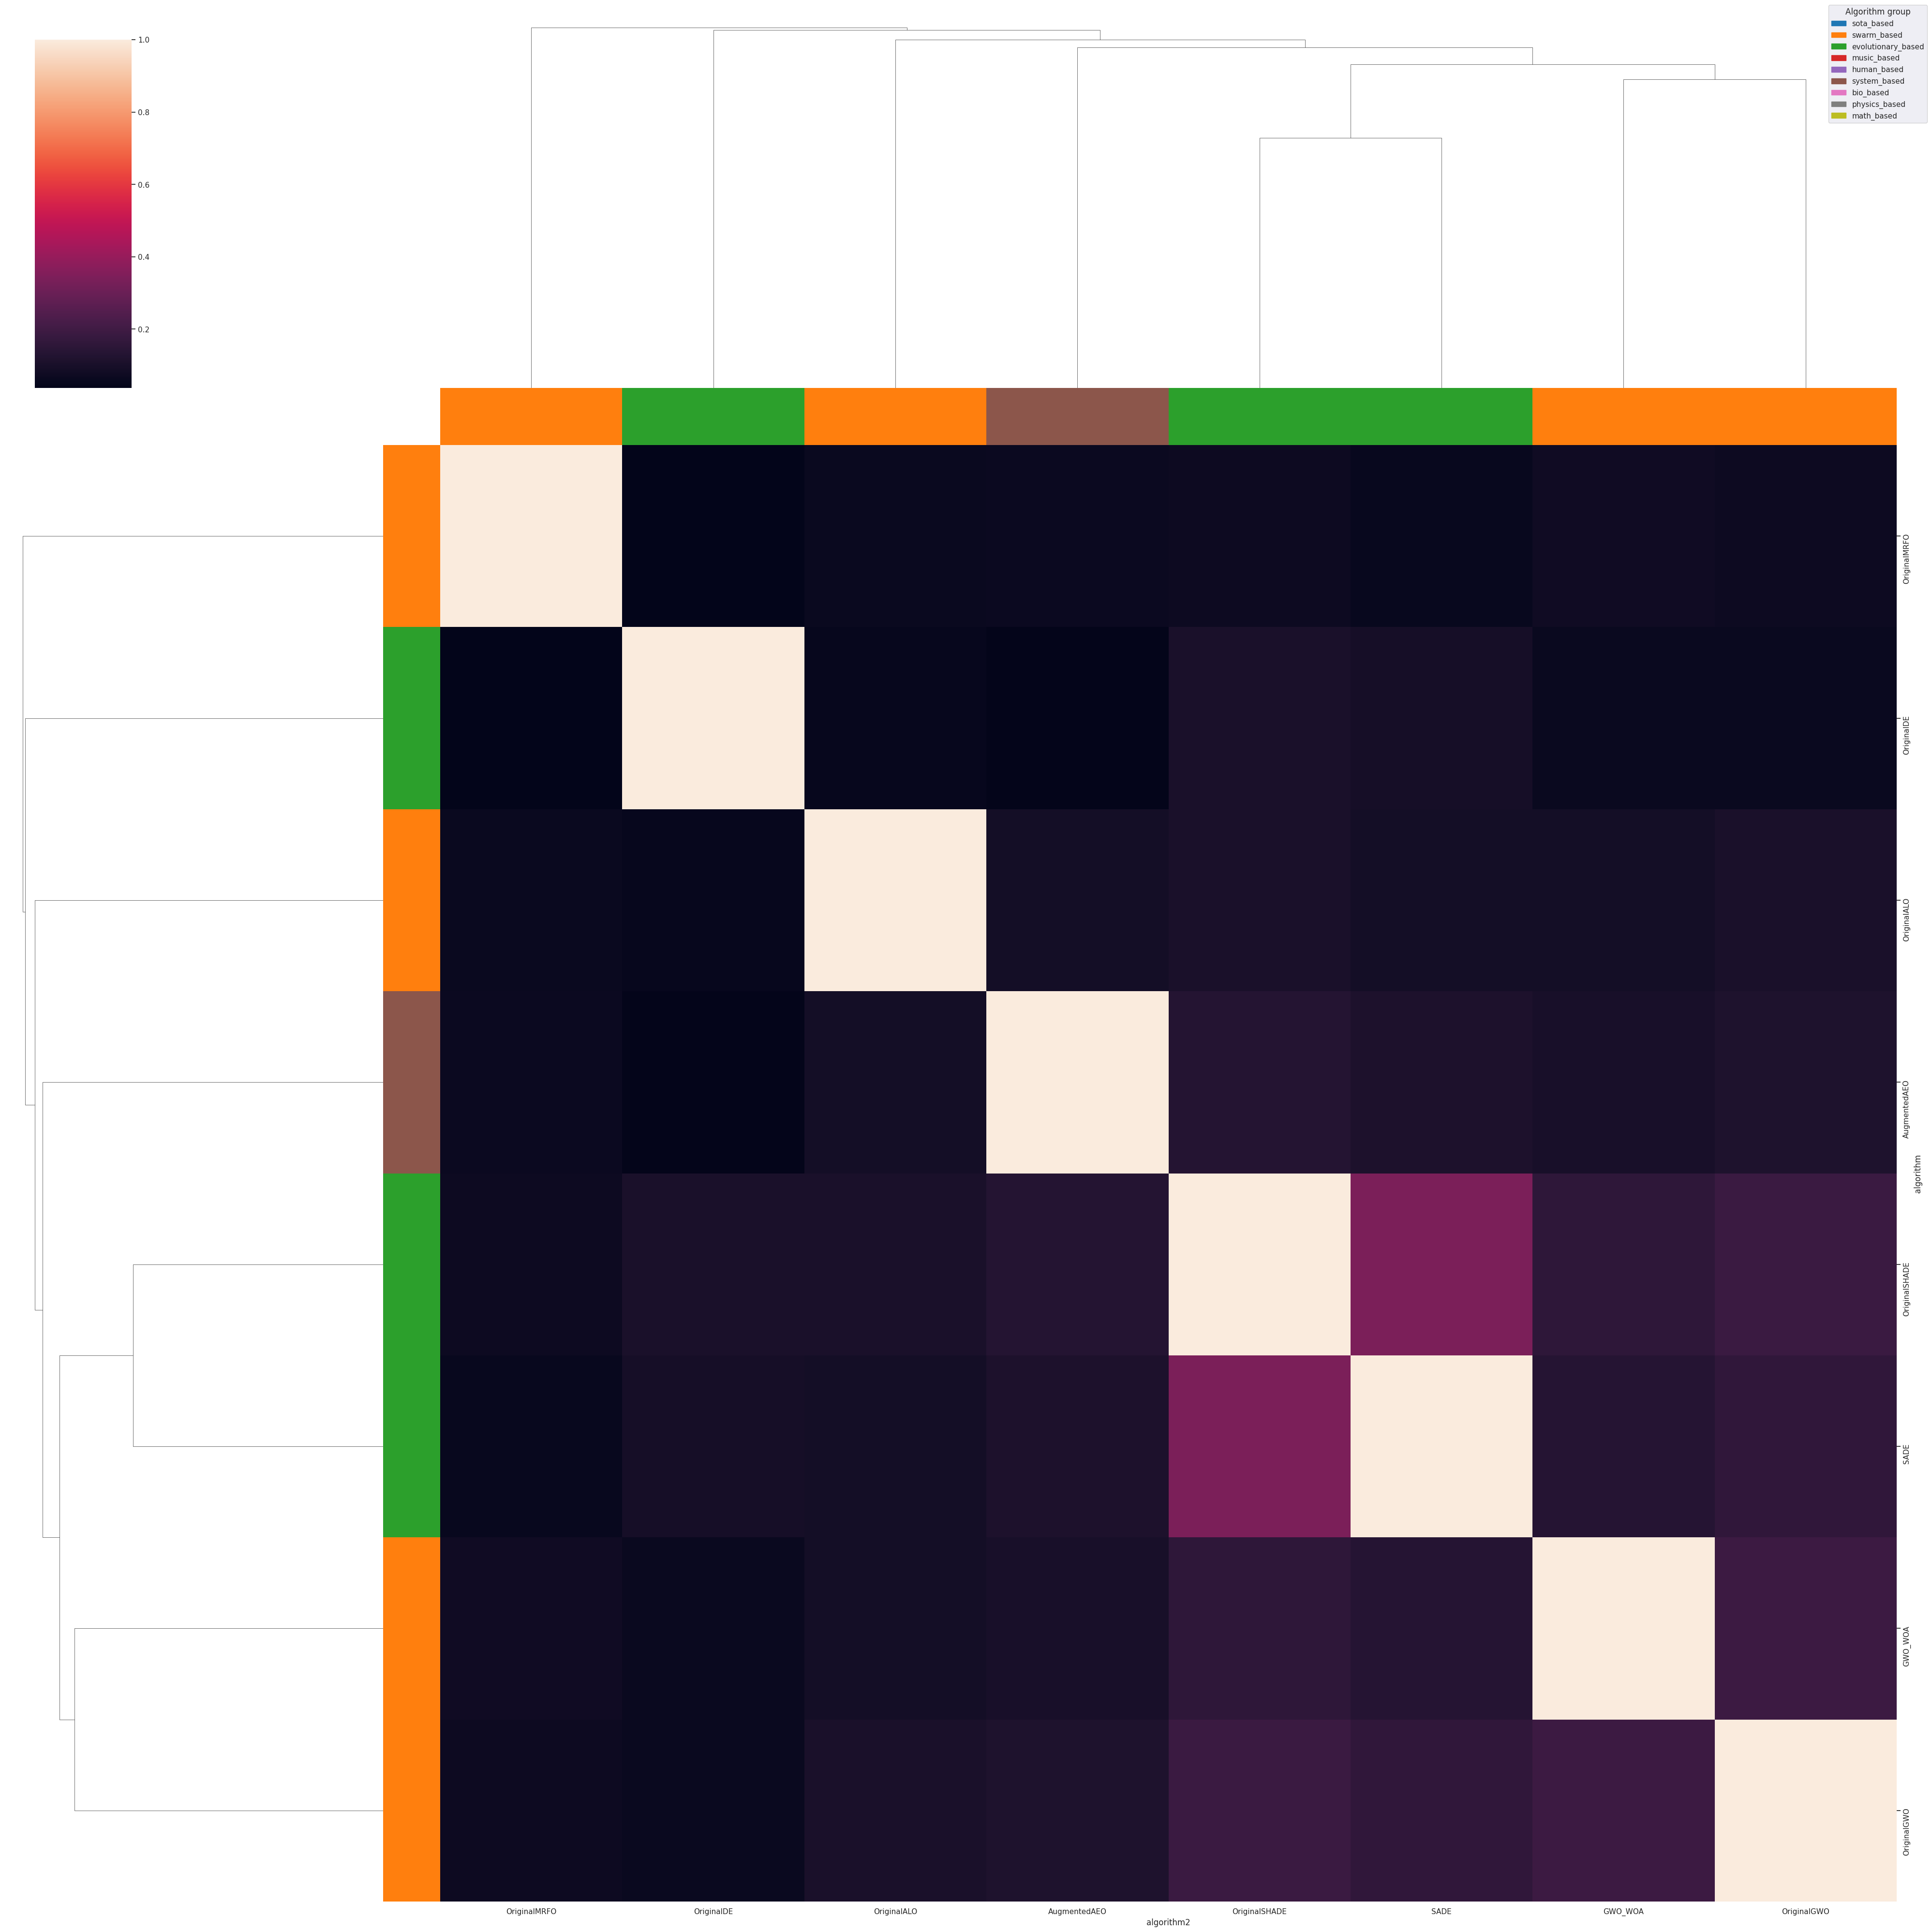

In [50]:
row_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.index]
col_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.columns]
sns.clustermap(cross_algorithm_similarity_pivoted, row_colors=row_colors, col_colors=col_colors,figsize=(40,40))
handles = [mpatches.Patch(color=color, label=label) for label, color in group_color.items()]
# Add legend to the clustermap
plt.legend(handles=handles, title='Algorithm group', bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure)

plt.savefig(f'figures_clustering_new_kmeans/algorithm_mean_similarity_clustermap_dim{dimension}.pdf')
#plt.show()
